In this script, we focus specifically on the ConvNeXt model family (tiny, small, base, large) to analyze how architecture scaling influences accuracy and inference time.

The goal is to verify if increasing model capacity (more parameters, more layers) provides a significant performance gain that justifies the additional computational cost.

In [1]:
import retinoto_py as fovea
args = fovea.Params(do_fovea=False)
args

Params(batch_size=128, num_workers=0, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=False, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-5.235987755982989, angle_margin=0.010166966516471823, mode='bilinear', padding_mode='zeros', model_name='convnext_base', num_epochs=100, subset_factor=1, optimizer_name='adamw', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.85, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False)

In [2]:
# List all ConvNeXt model variants available for testing
fovea.params.all_cn_model_names

['convnext_tiny', 'convnext_small', 'convnext_base', 'convnext_large']

# testing different networks

Benchmarking Loop: Comparing scaling effects on ConvNeXt architecture.

In [3]:
json_filename = args.data_cache / "14_model_cn_comparison.json"

# %rm {json_filename}  # FORCING RECOMPUTE

if json_filename.exists():
    results = fovea.pd.read_json(json_filename)
else:
    all_results = []
    # Evaluate across masking configurations and datasets
    for do_mask in [True, False]:
        for dataset in fovea.params.all_datasets:
            args = fovea.Params(do_mask=do_mask, do_fovea=False)
            val_loader = fovea.get_val_loader(args, dataset)
            for model_name in fovea.params.all_cn_model_names:
                args.do_mask = do_mask
                args.model_name = model_name
                model = fovea.load_model(args)
                param_stats = fovea.count_parameters(model)
                total_layers = fovea.count_layers(model)
                tic = fovea.time.time()
                accuracy = fovea.get_validation_accuracy(
                    args, model, val_loader, f"Model {args.model_name}\t dataset: {dataset}\t(do_mask={do_mask})"
                )
                toc = fovea.time.time()
                this_result = {
                    "model_name": model_name,
                    "do_mask": do_mask,
                    "dataset": dataset,
                    "accuracy": accuracy,
                    "wall_clock_time": (toc - tic) / len(val_loader.dataset),
                    "total_parameters": param_stats["total_parameters"],
                    "trainable_parameters": param_stats["trainable_parameters"],
                    "total_layers": total_layers,
                }
                all_results.append(this_result)
    results = fovea.pd.DataFrame(all_results)
    results.to_json(json_filename, orient="records", indent=2)

Model convnext_tiny	 dataset: full	(do_mask=True):   0%|          | 0/390 [00:00<?, ?it/s]

Model convnext_small	 dataset: full	(do_mask=True):   0%|          | 0/390 [00:00<?, ?it/s]

Model convnext_base	 dataset: full	(do_mask=True):   0%|          | 0/390 [00:00<?, ?it/s]

Model convnext_large	 dataset: full	(do_mask=True):   0%|          | 0/390 [00:00<?, ?it/s]

Model convnext_tiny	 dataset: bbox	(do_mask=True):   0%|          | 0/628 [00:00<?, ?it/s]

...

Model convnext_large	 dataset: full	(do_mask=False):   0%|          | 0/390 [00:00<?, ?it/s]

Model convnext_tiny	 dataset: bbox	(do_mask=False):   0%|          | 0/628 [00:00<?, ?it/s]

Model convnext_small	 dataset: bbox	(do_mask=False):   0%|          | 0/628 [00:00<?, ?it/s]

Model convnext_base	 dataset: bbox	(do_mask=False):   0%|          | 0/628 [00:00<?, ?it/s]

Model convnext_large	 dataset: bbox	(do_mask=False):   0%|          | 0/628 [00:00<?, ?it/s]

In [4]:
# Review the performance metrics table
results

,model_name,do_mask,dataset,accuracy,wall_clock_time,total_parameters,trainable_parameters,total_layers
0,convnext_tiny,True,full,0.817228,0.004588,28589128,28589128,203
1,convnext_small,True,full,0.825641,0.005286,50223688,50223688,383
2,convnext_base,True,full,0.831210,0.006492,88591464,88591464,383
3,convnext_large,True,full,0.837560,0.010986,197767336,197767336,383
4,convnext_tiny,True,bbox,0.760524,0.004915,28589128,28589128,203
5,convnext_small,True,bbox,0.773823,0.005820,50223688,50223688,383
6,convnext_base,True,bbox,0.779098,0.007102,88591464,88591464,383
7,convnext_large,True,bbox,0.788863,0.011318,197767336,197767336,383
8,convnext_tiny,False,full,0.824619,0.004370,28589128,28589128,203
9,convnext_small,False,full,0.834896,0.005348,50223688,50223688,383


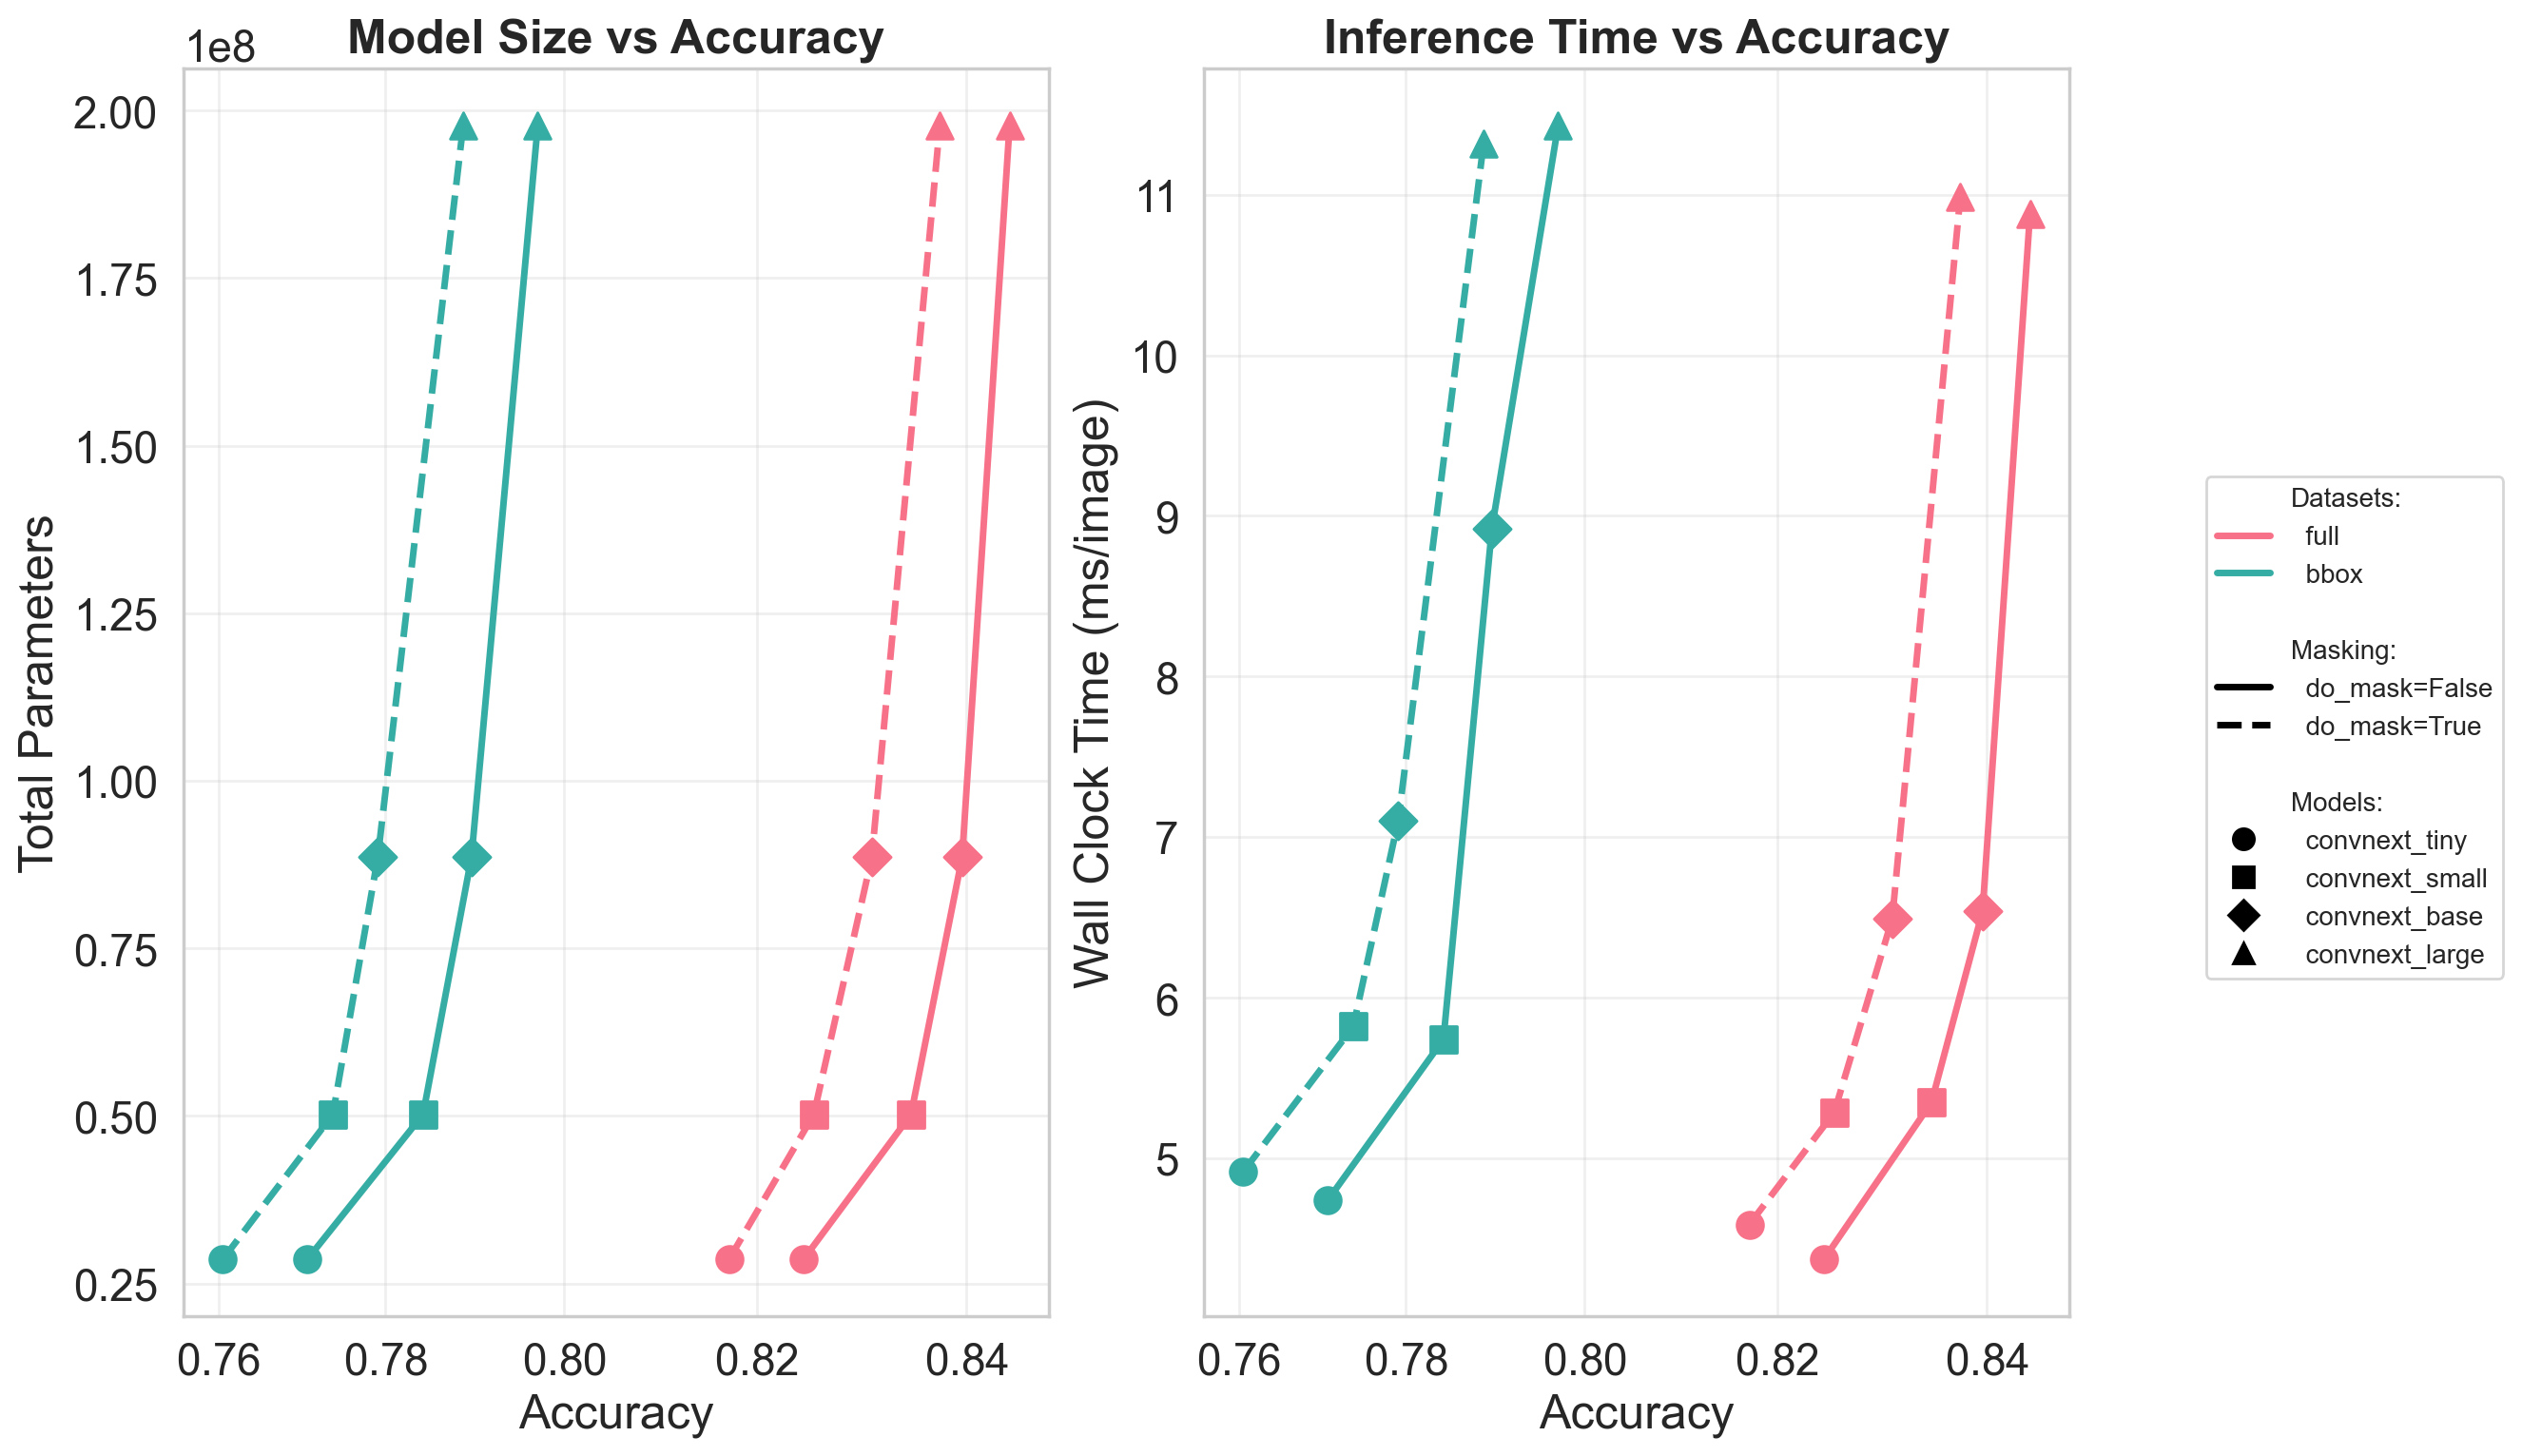

In [5]:
# Generate the comparison plots for ConvNeXt models
fig, axes = fovea.plot_model_comparison(
    results,
    fovea.params.all_cn_model_names,
    fovea.params.all_datasets,
    do_masks=[True, False],
    figures_folder=args.figures_folder,
    save_name="14_model_convnext",
)